# Informal RQ AC-GATE Workflow

This notebook is the `RQ_res` entry point for the isolated Informal AC-GATE experiments. It wires together the region-varying proxy loader, overlap and full-span suite runners, aggregation, sample-expansion audit, and seed-aggregated visualization artifacts without writing to the shared project output tree.

## RQ and Explicit Lag Construction

The operational RQ is whether formal economic processes have a learnable, interpretable, and AC-conditioned heterogeneous delay structure for the Informal outcome. In this isolated implementation, the visible lag structure is explicit because each candidate lag is enumerated before prediction.

For each region `i` and prediction year `t`, the model first forms a lag window from the formal sequence inputs: `x[i, t-1]`, `x[i, t-2]`, ..., `x[i, t-K]`, where `K=max_lag`. With the default overlap panel, `K=2`, so the 2023 test prediction uses the explicit formal histories from 2022 and 2021 after the warm-up years are supplied. With the expanded full-span income panel, the default `K=3` and the 2021-2023 test years each keep their own explicit lag window.

The AC/proxy channel is entity-level rather than target-derived. The overlap suite derives region-varying proxy signals from train-window formal summaries only: formal income level, formalization ratio, and formal capacity signal. The full-span suite uses the stable income/RPCYD series only and derives income level, recent income level, and income growth signals from 2006-2018 by default. In both cases the proxy construction excludes `y_t`.

The lag context used by the backbone is `sum_k omega[i, k] * h[i, t-k]`. The reported effective lag is `k_star[i] = sum_k k * omega[i, k]`. Therefore, `k_star` is not a hidden post-hoc label: it is the expectation of the model's learned distribution over the explicitly constructed lag window. The primary Omega figures in this notebook are seed-aggregated; the best-seed heatmap is retained only as a representative diagnostic.

In [ ]:
from pathlib import Path
import importlib
import subprocess
import sys

ROOT = Path.cwd()
if ROOT.name != 'CMDL':
    ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if path.name == 'CMDL')
RQ_ROOT = ROOT / 'RQ_res'
for path in [ROOT, RQ_ROOT]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import informal_acgate.sample_audit as sample_audit_module
import informal_acgate.visualize as visualize_module

sample_audit_module = importlib.reload(sample_audit_module)
visualize_module = importlib.reload(visualize_module)
build_sample_expansion_audit = sample_audit_module.build_sample_expansion_audit
build_visualizations = visualize_module.build_visualizations
load_comparison = visualize_module.load_comparison

OUTPUT_ROOT = RQ_ROOT / 'outputs' / 'informal_acgate'
SCENARIO = 'overlap_region_proxy'  # options: 'overlap_region_proxy', 'fullspan_region_proxy'
SUITE_DIR = OUTPUT_ROOT / ('suite_fullspan_region_proxy' if SCENARIO == 'fullspan_region_proxy' else 'suite_region_proxy')
FIGURE_DIR = OUTPUT_ROOT / ('figures_fullspan_region_proxy' if SCENARIO == 'fullspan_region_proxy' else 'figures_region_proxy')
AUDIT_DIR = OUTPUT_ROOT / 'sample_expansion_audit'
NOTEBOOK_ASSET_DIR = RQ_ROOT / 'notebook_assets'
NOTEBOOK_ASSET_DIR.mkdir(parents=True, exist_ok=True)
print('Workspace:', ROOT)
print('Scenario:', SCENARIO)
print('Suite output:', SUITE_DIR)
print('Figure output:', FIGURE_DIR)

Workspace: c:\DevSpace\PyDevspace\CMDL
Scenario: overlap_region_proxy
Suite output: c:\DevSpace\PyDevspace\CMDL\RQ_res\outputs\informal_acgate\suite_region_proxy
Figure output: c:\DevSpace\PyDevspace\CMDL\RQ_res\outputs\informal_acgate\figures_region_proxy


## Run Interface

The cell below is intentionally parameterized. Leave `RUN_EXPERIMENTS=False` when you only want to inspect existing results. Set `SCENARIO='fullspan_region_proxy'` in the setup cell to switch the notebook to the expanded 2006-2023 income/RPCYD suite.

In [7]:
RUN_SAMPLE_AUDIT = True
RUN_EXPERIMENTS = False
FORCE = False
DEVICE = 'cpu'
SEEDS = list(range(20))
EPOCHS = 80
PATIENCE = 15
MAX_LAG = None  # None uses suite defaults: overlap=2, fullspan=3

if RUN_SAMPLE_AUDIT:
    audit_paths = build_sample_expansion_audit(output_dir=AUDIT_DIR)
    print('Sample audit artifacts:')
    for key, value in audit_paths.items():
        print(f'{key}: {value}')

command = [
    sys.executable,
    str(RQ_ROOT / 'informal_acgate' / 'suite.py'),
    '--scenario', SCENARIO,
    '--device', DEVICE,
    '--epochs', str(EPOCHS),
    '--patience', str(PATIENCE),
    '--seeds', *[str(seed) for seed in SEEDS],
]
if MAX_LAG is not None:
    command.extend(['--max-lag', str(MAX_LAG)])
if FORCE:
    command.append('--force')

print('Command:')
print(' '.join(command))
if RUN_EXPERIMENTS:
    subprocess.run(command, cwd=ROOT, check=True)
else:
    print('RUN_EXPERIMENTS is False; using existing files if present.')

Sample audit artifacts:
panel_summary_csv: C:\DevSpace\PyDevspace\CMDL\RQ_res\outputs\informal_acgate\sample_expansion_audit\panel_summary.csv
feature_year_support_csv: C:\DevSpace\PyDevspace\CMDL\RQ_res\outputs\informal_acgate\sample_expansion_audit\feature_year_support.csv
effective_sample_counts_csv: C:\DevSpace\PyDevspace\CMDL\RQ_res\outputs\informal_acgate\sample_expansion_audit\effective_sample_counts.csv
feature_year_support_heatmap: C:\DevSpace\PyDevspace\CMDL\RQ_res\outputs\informal_acgate\sample_expansion_audit\feature_year_support_heatmap.png
effective_sample_counts: C:\DevSpace\PyDevspace\CMDL\RQ_res\outputs\informal_acgate\sample_expansion_audit\effective_sample_counts.png
Command:
c:\Users\42155\anaconda3\envs\PTenv\python.exe c:\DevSpace\PyDevspace\CMDL\RQ_res\informal_acgate\suite.py --scenario overlap_region_proxy --device cpu --epochs 80 --patience 15 --seeds 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19
RUN_EXPERIMENTS is False; using existing files if present.


## Aggregate Results

Aggregation scans the selected scenario run folders for `summary.json`, writes `comparison.csv`, and exposes the seed-level table for inspection. The table includes split years and effective supervised sample counts after lag warm-up.

In [8]:
comparison = load_comparison(output_dir=SUITE_DIR)
selected = [
    'scenario', 'run_group', 'experiment', 'seed', 'best_epoch',
    'max_lag', 'train_effective_samples', 'val_effective_samples', 'test_effective_samples',
    'test_mse', 'test_mae', 'test_kstar_proxy_spearman_adjusted_rho',
    'test_kstar_std', 'test_lag_gate_sensitivity_range', 'test_omega_entropy_mean',
]
available = [column for column in selected if column in comparison.columns]
comparison[available].sort_values(['run_group', 'seed']).head(20)

,scenario,run_group,experiment,seed,best_epoch,max_lag,train_effective_samples,val_effective_samples,test_effective_samples,test_mse,test_mae,test_kstar_proxy_spearman_adjusted_rho,test_kstar_std,test_lag_gate_sensitivity_range,test_omega_entropy_mean
0,overlap_region_proxy,Multiseq CMDL,multiseq_overlap_region_proxy_cmdl_seed0,0,10,2,21,21,21,25.265525,5.022231,-0.000000,7.885822e-07,1.549721e-06,0.467596
1,overlap_region_proxy,Multiseq CMDL,multiseq_overlap_region_proxy_cmdl_seed1,1,11,2,21,21,21,27.576806,5.246713,-0.000000,3.106109e-07,8.344650e-07,0.473254
12,overlap_region_proxy,Multiseq CMDL,multiseq_overlap_region_proxy_cmdl_seed2,2,9,2,21,21,21,28.122650,5.290754,-0.000000,6.270046e-08,2.384186e-07,0.264393
13,overlap_region_proxy,Multiseq CMDL,multiseq_overlap_region_proxy_cmdl_seed3,3,14,2,21,21,21,29.263741,5.405109,-0.451948,1.566222e-03,3.107667e-03,0.471760
14,overlap_region_proxy,Multiseq CMDL,multiseq_overlap_region_proxy_cmdl_seed4,4,9,2,21,21,21,24.476898,4.943199,0.807792,8.251205e-05,2.580881e-04,0.467440
15,overlap_region_proxy,Multiseq CMDL,multiseq_overlap_region_proxy_cmdl_seed5,5,8,2,21,21,21,36.912172,6.051717,NaN,0.000000e+00,0.000000e+00,0.481585
16,overlap_region_proxy,Multiseq CMDL,multiseq_overlap_region_proxy_cmdl_seed6,6,11,2,21,21,21,26.503926,5.137131,0.244885,7.856062e-06,1.668930e-05,0.275432
17,overlap_region_proxy,Multiseq CMDL,multiseq_overlap_region_proxy_cmdl_seed7,7,11,2,21,21,21,27.747963,5.260793,-0.000000,6.037547e-07,1.668930e-06,0.261300
18,overlap_region_proxy,Multiseq CMDL,multiseq_overlap_region_proxy_cmdl_seed8,8,31,2,21,21,21,30.450371,5.508751,-0.000000,1.350514e-07,3.576279e-07,0.266775
19,overlap_region_proxy,Multiseq CMDL,multiseq_overlap_region_proxy_cmdl_seed9,9,11,2,21,21,21,26.362995,5.131627,-0.000000,5.666974e-07,1.788139e-06,0.470660


## Visualization Interface

The visualization step writes figures plus compact CSV summaries under the scenario-specific figure directory. The primary mechanism plots now use seed-aggregated Omega and k* summaries; the best-seed heatmap remains available as a representative diagnostic rather than the main mechanism figure.

In [ ]:
import importlib
import informal_acgate.visualize as visualize_module

visualize_module = importlib.reload(visualize_module)
build_visualizations = visualize_module.build_visualizations
load_comparison = visualize_module.load_comparison
figure_paths = build_visualizations(output_dir=SUITE_DIR, figure_dir=FIGURE_DIR)
figure_paths

{'comparison_csv': 'C:\\DevSpace\\PyDevspace\\CMDL\\RQ_res\\outputs\\informal_acgate\\figures_region_proxy\\comparison_for_figures.csv',
 'seed_summary_csv': 'C:\\DevSpace\\PyDevspace\\CMDL\\RQ_res\\outputs\\informal_acgate\\figures_region_proxy\\seed_summary.csv',
 'test_error_by_model': 'C:\\DevSpace\\PyDevspace\\CMDL\\RQ_res\\outputs\\informal_acgate\\figures_region_proxy\\test_error_by_model.png',
 'mechanism_metrics_by_model': 'C:\\DevSpace\\PyDevspace\\CMDL\\RQ_res\\outputs\\informal_acgate\\figures_region_proxy\\mechanism_metrics_by_model.png',
 'seed_stability_mse': 'C:\\DevSpace\\PyDevspace\\CMDL\\RQ_res\\outputs\\informal_acgate\\figures_region_proxy\\seed_stability_mse.png',
 'best_multiseq_cmdl_omega_heatmap': 'C:\\DevSpace\\PyDevspace\\CMDL\\RQ_res\\outputs\\informal_acgate\\figures_region_proxy\\best_multiseq_cmdl_omega_heatmap.png',
 'best_multiseq_cmdl_proxy_kstar': 'C:\\DevSpace\\PyDevspace\\CMDL\\RQ_res\\outputs\\informal_acgate\\figures_region_proxy\\best_multiseq_cm

test_error_by_model


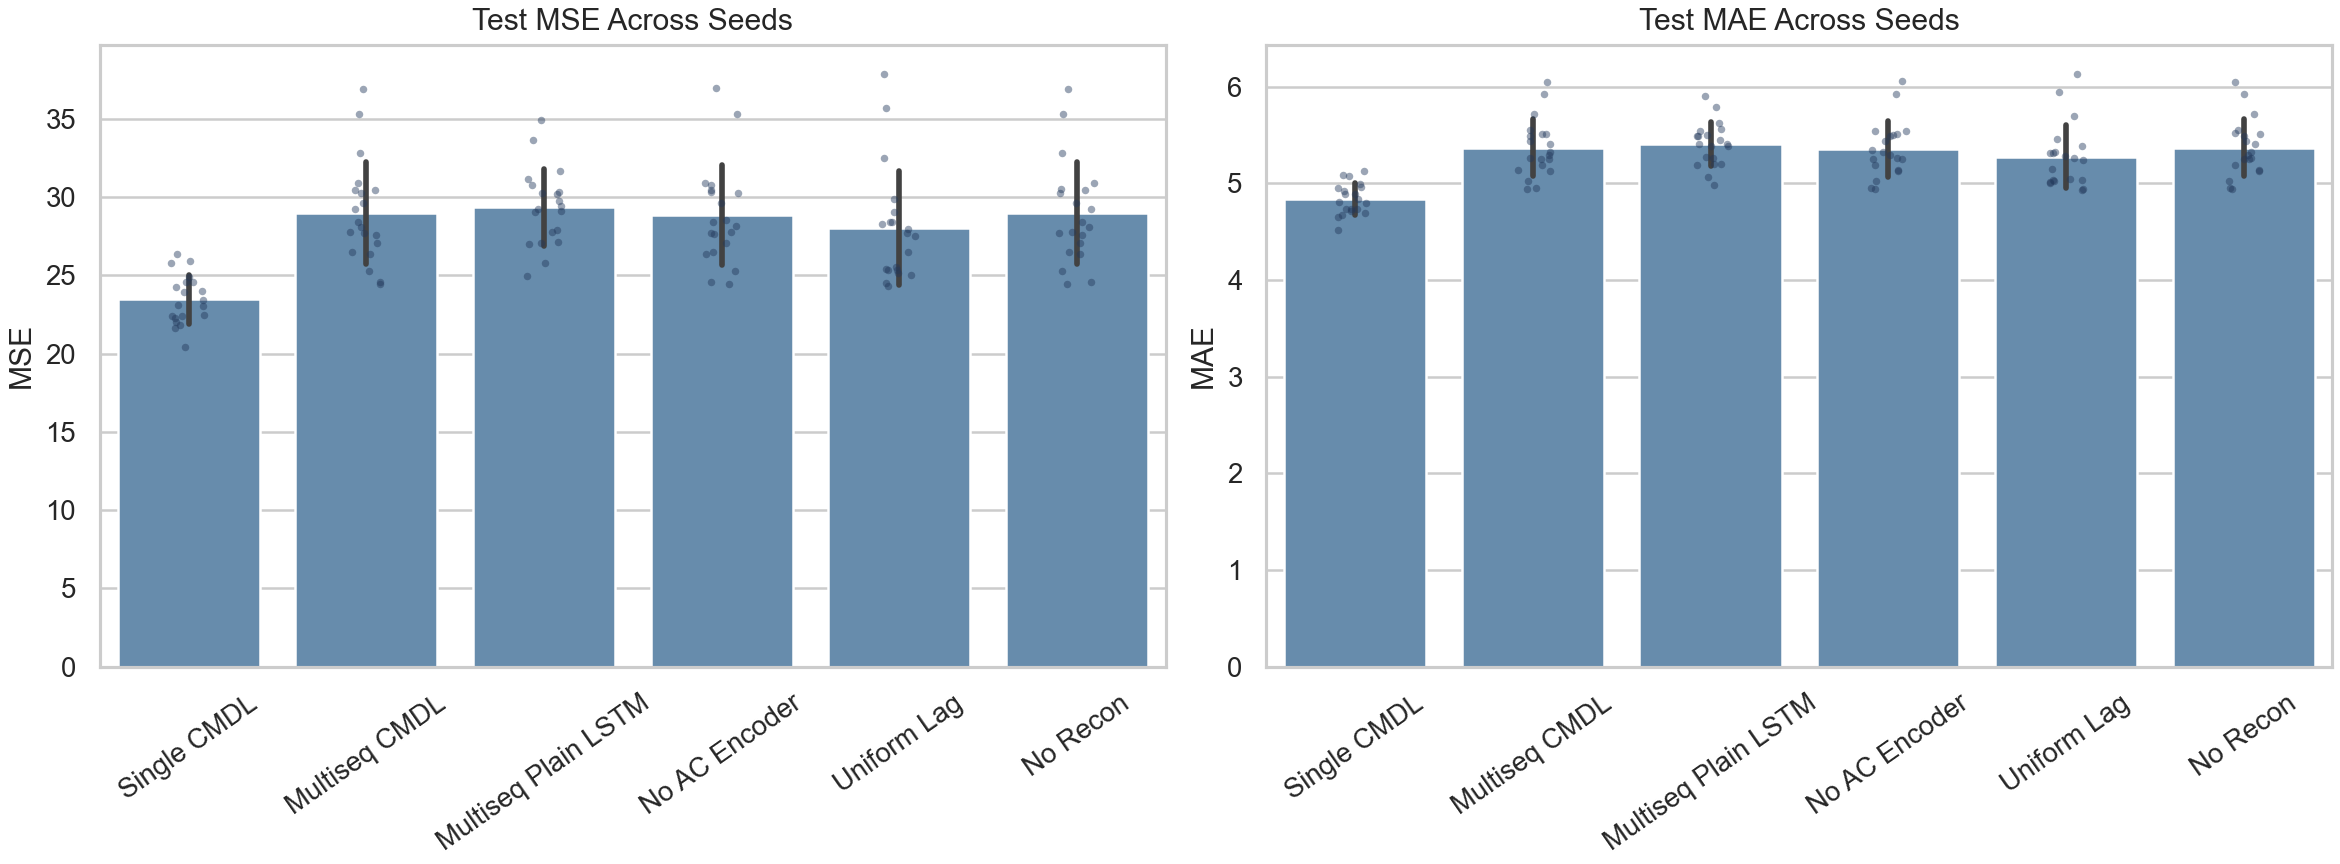

mechanism_metrics_by_model


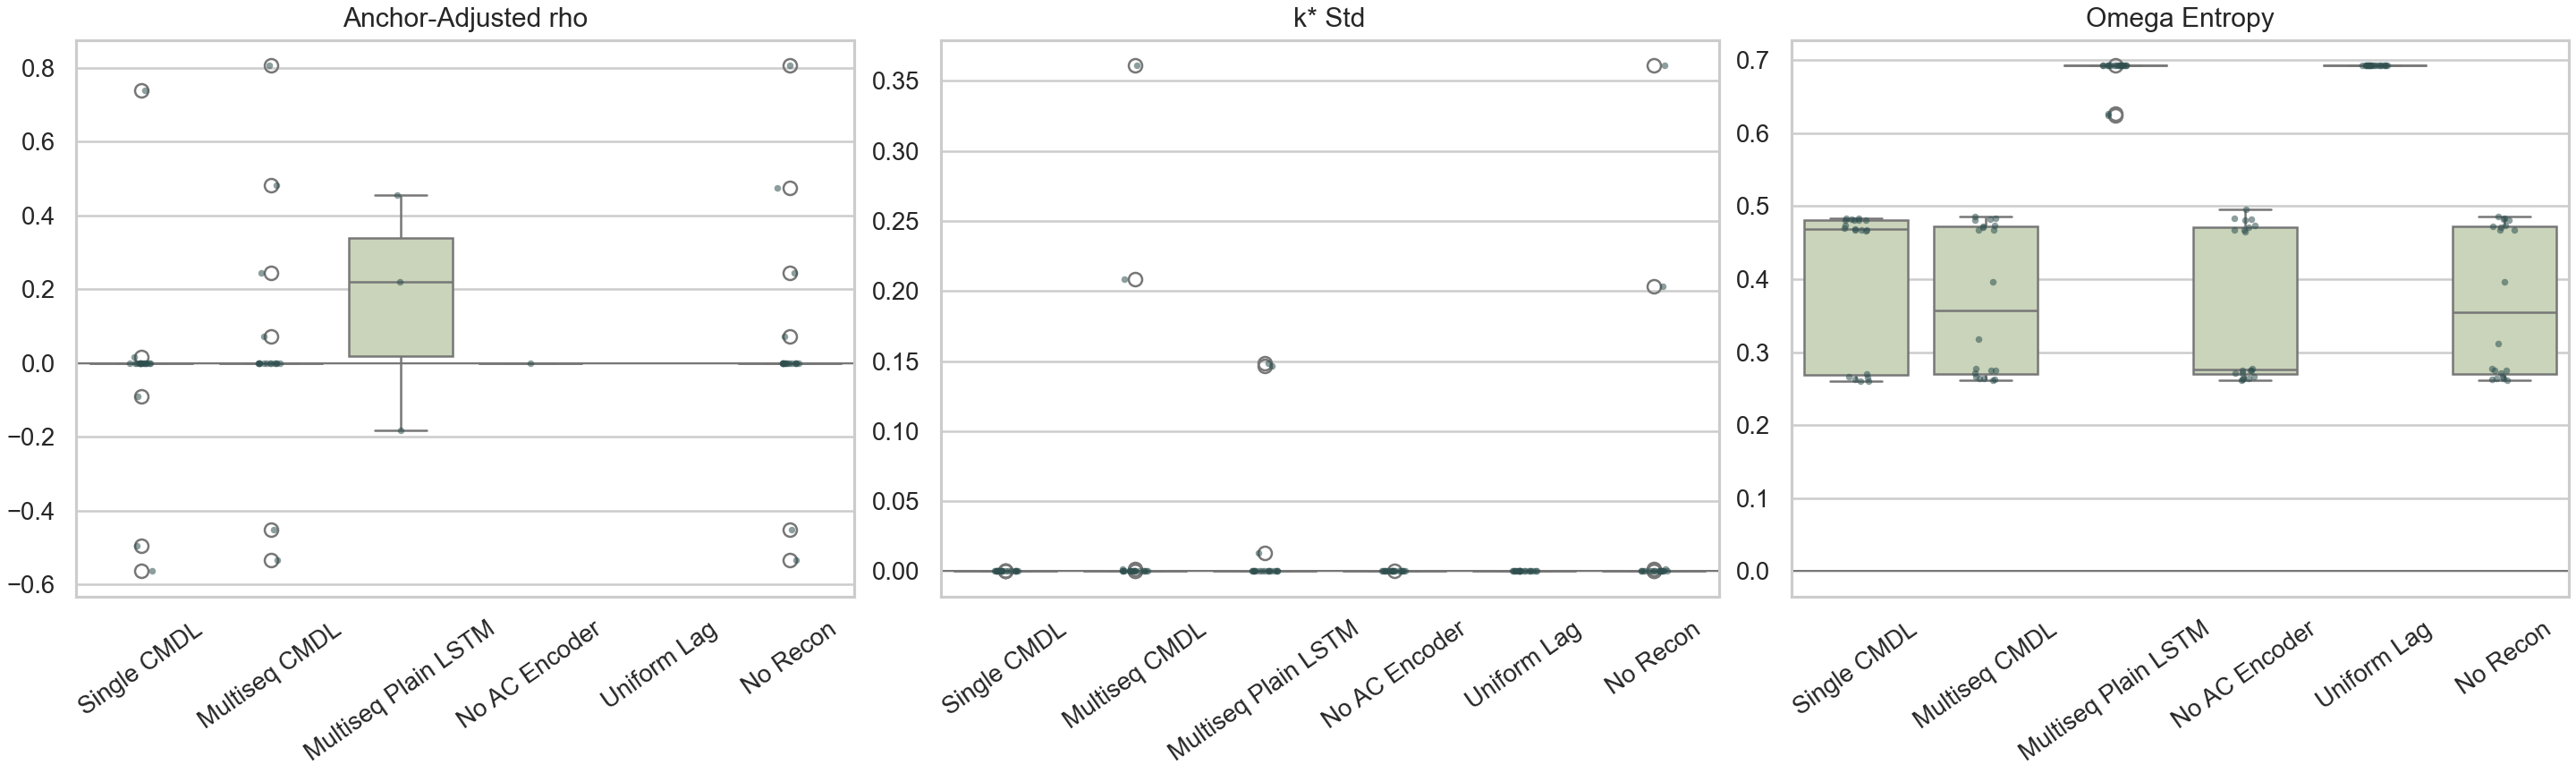

seed_stability_mse


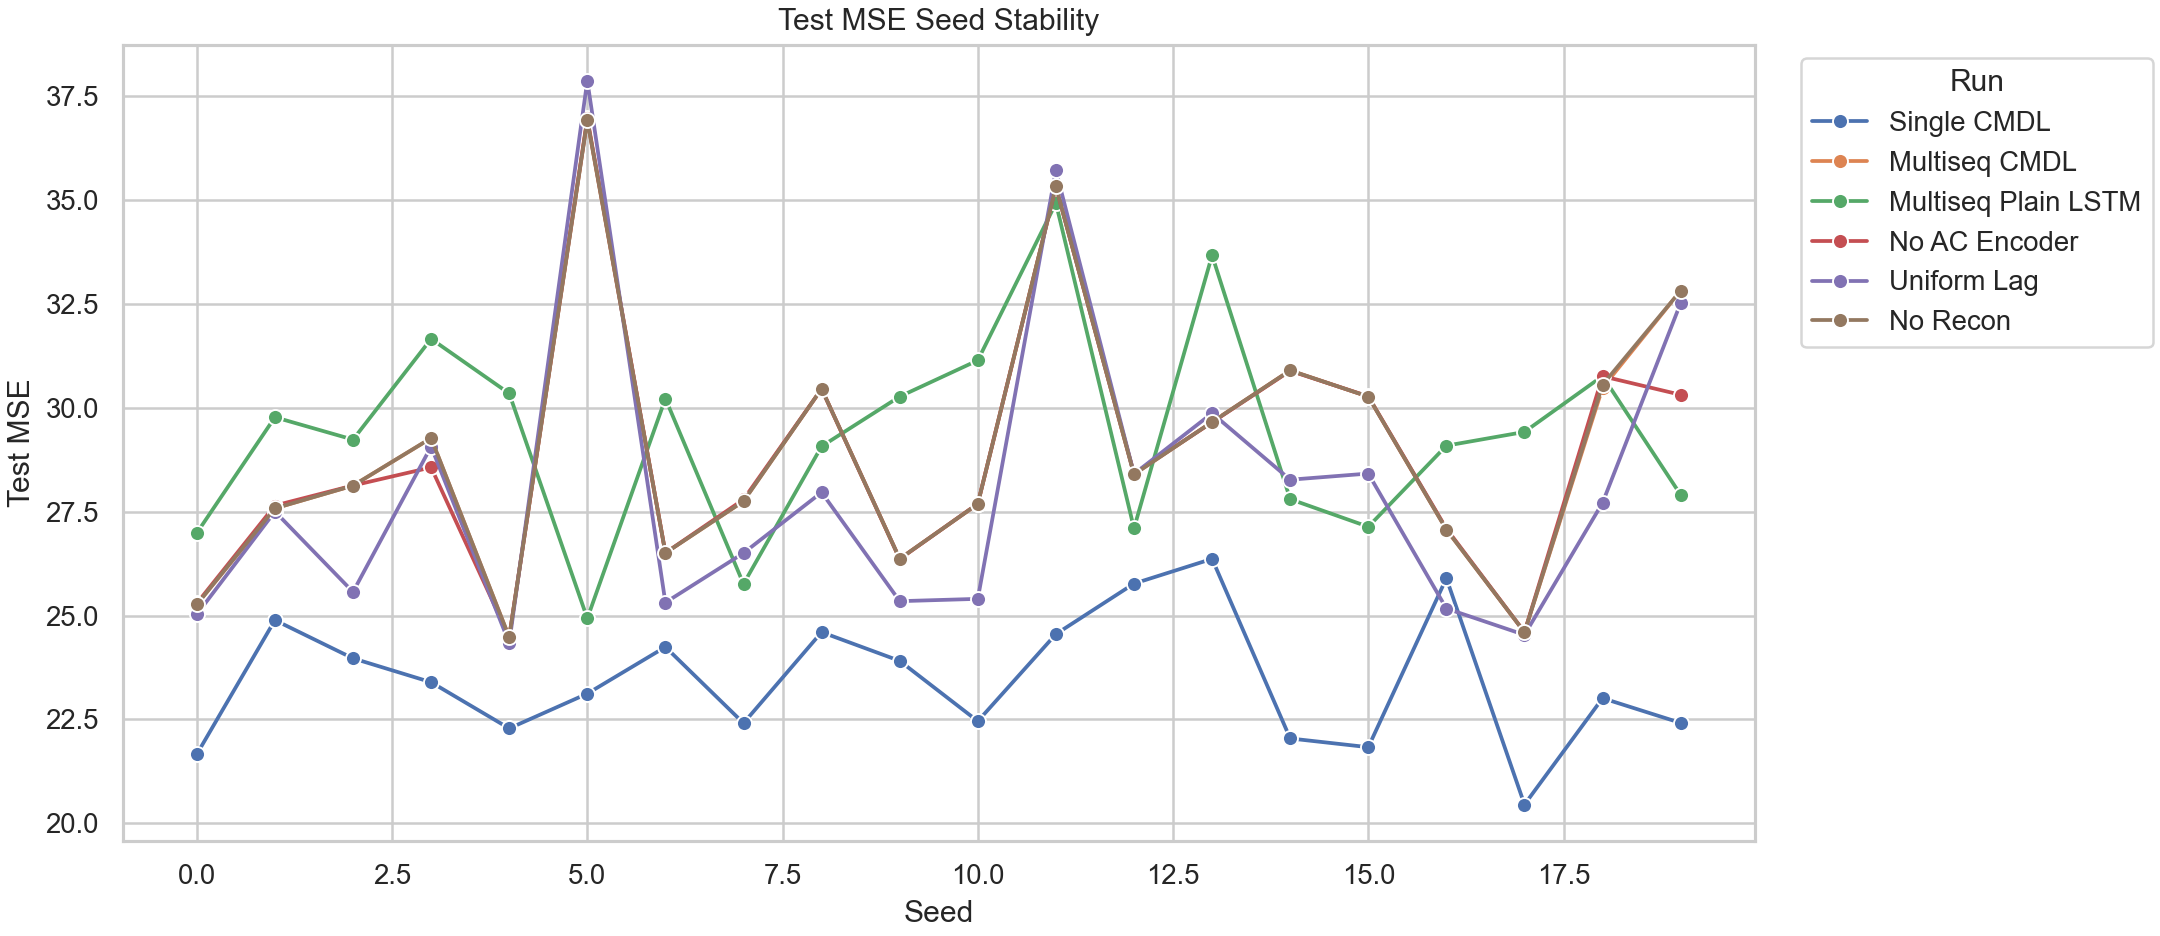

seed_mean_cmdl_omega_heatmap


KeyError: 'seed_mean_cmdl_omega_heatmap'

In [ ]:
from pathlib import Path
import importlib
from IPython.display import Image, display
import informal_acgate.visualize as visualize_module

requested_figure_keys = [
    'test_error_by_model',
    'mechanism_metrics_by_model',
    'seed_stability_mse',
    'seed_mean_cmdl_omega_heatmap',
    'seed_std_cmdl_omega_heatmap',
    'year_lag_cmdl_omega_heatmap',
    'cmdl_kstar_distribution',
    'seed_mean_cmdl_proxy_kstar',
    'best_cmdl_omega_heatmap',
]

missing_keys = [key for key in requested_figure_keys if key not in figure_paths]
if missing_keys:
    visualize_module = importlib.reload(visualize_module)
    figure_paths = visualize_module.build_visualizations(output_dir=SUITE_DIR, figure_dir=FIGURE_DIR)
    missing_keys = [key for key in requested_figure_keys if key not in figure_paths]

if missing_keys:
    raise KeyError(f'Missing visualization artifacts after rebuild: {missing_keys}')

for key in requested_figure_keys:
    figure_path = Path(figure_paths[key])
    print(key)
    if not figure_path.exists():
        raise FileNotFoundError(f'Missing figure file: {figure_path}')
    display(Image(filename=str(figure_path)))

## Reading the RQ Evidence

The strongest RQ support would require positive seed share for anchor-adjusted proxy-k* alignment, nonzero `kstar_std`, nonzero lag-gate sensitivity, and no collapse in omega entropy. Prediction metrics such as MSE and MAE remain calibration checks; they do not by themselves establish the mechanism claim.

Because the overlap panel evaluates only one held-out year after lag warm-up, R2 can still be degenerate when the target has little cross-sectional variation. The full-span income/RPCYD scenario expands the effective sample by adding more prediction years, but it narrows the substantive claim to long-horizon income dynamics rather than the richer RYDGDP formalization bundle.

Read the seed-mean Omega heatmap as the main lag-gate summary. Read the seed-std Omega heatmap and k* distribution as stability checks. The best-seed Omega heatmap is useful for inspecting one representative run, but it should not be treated as the cross-seed mechanism estimate.